# How a Real LLM Predicts the Next Token in Oilfield Text

**Notebook 1 of a planned series: next-token prediction only.**

This notebook does one thing, and does it honestly: it loads a real, open-source,
locally-run language model, feeds it a realistic drilling/completions/intervention
sentence, and shows you the *actual* logits and probabilities the model assigns to
every candidate next token. Nothing here is invented, simulated, or hard-coded.

We deliberately stop before generation, decoding strategies (temperature,
sampling, top-k/top-p), attention visualization, or embedding analysis — those are
each a notebook of their own. Keeping the scope to a single next-token prediction
step keeps every number in this notebook traceable to the loaded model, and it is
already enough to explain a major part of how an LLM produces text.

## Learning objectives

By the end of this notebook you should be able to answer:

1. What does a language model actually predict?
2. What is a token (and why is it not the same thing as a word)?
3. What is a logit?
4. How does softmax turn logits into probabilities?
5. Which candidate tokens does a real, loaded model assign the highest
   probability to, for a specific oilfield sentence?
6. Why can changing a few words in an oilfield sentence change the predicted
   next token?
7. Why is the predicted token not simply the output of a hard-coded keyword
   rule (e.g. `if "POOH" in text: ...`)?
8. Why should we avoid claiming to know exactly *why* an internal neural
   network chose a token?
9. What can we legitimately infer from observed changes in model
   probabilities — and what can't we?

Decoding strategies (greedy vs. sampling, temperature, top-k/top-p) and deeper
interpretability methods (attention, embeddings, attribution) are intentionally
left for a follow-up notebook so this one stays focused and verifiable.


## 1. What problem are we investigating?

Oilfield language is full of short, overloaded abbreviations. Take **POOH**
("pull out of hole"). It shows up during drilling, completions, workover,
intervention, wireline logging, coiled tubing cleanouts, and fishing jobs. The
word alone tells you almost nothing about what happens next in the sentence —
the *surrounding context* does.

That makes oilfield text a good, concrete way to show what a language model is
actually doing under the hood: it is not looking up "POOH" in a dictionary of
operations. It is processing the whole sequence of tokens it has seen so far
and producing a probability for every token in its vocabulary being the next
one.

This notebook shows that process end to end, for one prediction step at a
time:

```
prompt -> tokenizer -> token IDs -> transformer -> logits -> softmax -> probabilities -> top candidates
```

and then changes the oilfield context around a sentence to see how that
distribution moves — using only real numbers read out of a real model.


## Installation (run once)

Uncomment and run the cell below the first time you use this notebook. You do
not need to run it every time — once the packages are installed, skip it.


In [1]:
# Run this once. After the packages are installed you can leave this commented out.
# %pip install torch transformers accelerate pandas matplotlib numpy
print("If an import in the next cell fails, uncomment and run the pip install line above, then re-run this notebook.")


If an import in the next cell fails, uncomment and run the pip install line above, then re-run this notebook.


## 2. Load the real language model

We use **Qwen2.5-1.5B-Instruct**, an open-source instruction-tuned model small
enough to run on a modern MacBook (including Apple Silicon via the MPS
backend), CPU-only, or CUDA if available. It is downloaded once from Hugging
Face and cached locally (~3 GB); after that, the notebook runs fully offline.

> If Qwen2.5-1.5B-Instruct fails to load in your environment, a fallback model
> is defined below and the notebook will tell you clearly which model actually
> ran — it will never silently substitute a model without saying so.

All randomness sources are seeded for reproducibility, and we detect Apple
Silicon's MPS backend, then CUDA, then fall back to CPU.


In [2]:
import random
import platform
import sys

import numpy as np
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PRIMARY_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
FALLBACK_MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"  # used only if the primary model fails to load

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

# Half precision is only used on accelerated backends; CPU stays in float32 for numerical stability.
DTYPE = torch.float16 if DEVICE in ("mps", "cuda") else torch.float32

print(f"Python version:       {sys.version.split()[0]}")
print(f"Platform:             {platform.platform()}")
print(f"PyTorch version:      {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")
print(f"Selected device:      {DEVICE}")
print(f"Selected dtype:       {DTYPE}")


Python version:       3.12.13
Platform:             macOS-26.6.2-arm64-arm-64bit
PyTorch version:      2.14.0
Transformers version: 5.16.1
Selected device:      mps
Selected dtype:       torch.float16


In [3]:
def load_model(model_name: str = PRIMARY_MODEL_NAME):
    '''Load a causal language model and its tokenizer onto the selected device.

    Falls back to FALLBACK_MODEL_NAME if the primary model cannot be loaded,
    and always reports which model actually ended up running.
    '''
    try:
        tok = AutoTokenizer.from_pretrained(model_name)
        mdl = AutoModelForCausalLM.from_pretrained(model_name, dtype=DTYPE)
        mdl.to(DEVICE)
        mdl.eval()
        return tok, mdl, model_name
    except Exception as exc:  # noqa: BLE001 - we want to report and fall back, not crash the notebook
        print(f"Could not load '{model_name}' ({exc}). Falling back to '{FALLBACK_MODEL_NAME}'.")
        tok = AutoTokenizer.from_pretrained(FALLBACK_MODEL_NAME)
        mdl = AutoModelForCausalLM.from_pretrained(FALLBACK_MODEL_NAME, dtype=DTYPE)
        mdl.to(DEVICE)
        mdl.eval()
        return tok, mdl, FALLBACK_MODEL_NAME


tokenizer, model, MODEL_NAME = load_model()
print(f"\nModel actually loaded and used in this notebook: {MODEL_NAME}")
print(f"Vocabulary size: {model.config.vocab_size:,} tokens")


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]


Model actually loaded and used in this notebook: Qwen/Qwen2.5-1.5B-Instruct
Vocabulary size: 151,936 tokens


## 3. A simple oilfield prompt

Our primary example sentence is deliberately left unfinished — we want to see
what the model predicts as the *next* token:

> "The crew pulled out of hole with the worn PDC bit and prepared to run a new"

Because this is a next-token *completion* task rather than a chat exchange, we
pass this sentence to the model as plain text — no chat template, no system
prompt, no special control tokens. This keeps the mechanics easy to follow:
what you see below is exactly, character for character, what goes into the
tokenizer. (Section 19 discusses how a chat template would change this.)


In [4]:
PROMPT = "The crew pulled out of hole with the worn PDC bit and prepared to run a new"
print(repr(PROMPT))


'The crew pulled out of hole with the worn PDC bit and prepared to run a new'


## 4. Tokenization

A language model does not read words. It reads **tokens** — integer IDs from a
fixed vocabulary that the tokenizer maps text to. A token can be:

- a whole word (`' bit'`)
- part of a word (`'ing'`)
- punctuation
- whitespace attached to a word (`' the'` — note the leading space)
- a number or technical fragment

This matters a lot for oilfield text, because domain terms and acronyms often
do **not** map to a single token. We use `repr()` below so leading spaces are
visible instead of silently disappearing.


In [5]:
def tokenize_prompt(prompt: str):
    '''Tokenize a prompt and return (input_ids tensor, list of decoded token strings).'''
    encoded = tokenizer(prompt, return_tensors="pt")
    input_ids = encoded["input_ids"][0]
    decoded_tokens = [tokenizer.decode([tid]) for tid in input_ids]
    return encoded, input_ids, decoded_tokens


encoded, input_ids, decoded_tokens = tokenize_prompt(PROMPT)

import pandas as pd

token_table = pd.DataFrame({
    "position": range(len(input_ids)),
    "token_id": input_ids.tolist(),
    "decoded_token_repr": [repr(t) for t in decoded_tokens],
})
print(f"The prompt was split into {len(input_ids)} tokens.\n")
token_table


The prompt was split into 18 tokens.



,position,token_id,decoded_token_repr
0,0,785,'The'
1,1,13627,' crew'
2,2,13238,' pulled'
3,3,700,' out'
4,4,315,' of'
5,5,14178,' hole'
6,6,448,' with'
7,7,279,' the'
8,8,23704,' worn'
9,9,393,' P'


**Interpretation:** notice that some familiar oilfield words may split into
more than one token, and that most word-tokens carry a leading space (that
space is how the tokenizer marks "a new word started here"). This is real
tokenizer output for the real prompt above — nothing here is illustrative.


### 4a. Oilfield terms are often multiple tokens

Let's check how the tokenizer handles common oilfield vocabulary. A term
being split into several tokens is not a sign the model "doesn't understand"
it — it just means the term wasn't common enough in the tokenizer's training
data to earn its own single token. We should not read more into the token
count than that.


In [6]:
oilfield_terms = [
    "completion", "perforation", "coiled tubing", "wellbore", "PDC",
    "BHA", "SCSSV", "ESP", "packer", "fracturing", "POOH", "RIH", "TCP",
]

def tokenize_term(term: str):
    ids = tokenizer.encode(term, add_special_tokens=False)
    pieces = [tokenizer.decode([tid]) for tid in ids]
    return ids, pieces

term_rows = []
for term in oilfield_terms:
    ids, pieces = tokenize_term(term)
    term_rows.append({
        "term": term,
        "n_tokens": len(ids),
        "token_ids": ids,
        "decoded_pieces": [repr(p) for p in pieces],
    })

term_table = pd.DataFrame(term_rows)
term_table


,term,n_tokens,token_ids,decoded_pieces
0,completion,1,[43312],['completion']
1,perforation,3,"[712, 1958, 367]","['per', 'for', 'ation']"
2,coiled tubing,3,"[1015, 2181, 73902]","['co', 'iled', ' tubing']"
3,wellbore,3,"[9157, 65, 460]","['well', 'b', 'ore']"
4,PDC,2,"[47, 5626]","['P', 'DC']"
5,BHA,2,"[33, 17020]","['B', 'HA']"
6,SCSSV,3,"[3540, 1220, 53]","['SC', 'SS', 'V']"
7,ESP,1,[56229],['ESP']
8,packer,2,"[4748, 261]","['pack', 'er']"
9,fracturing,3,"[1626, 531, 1677]","['fr', 'act', 'uring']"


## 5. Run the prompt through the transformer and extract logits

Now we run the tokenized prompt through the model itself. We use
`torch.no_grad()` because we are only doing inference, not training — this
saves memory and computation.

The model returns `outputs.logits`, a tensor of shape
`(batch_size, sequence_length, vocab_size)`. We want the prediction for the
*next* token after the *last* token of our prompt, which lives at:

```python
outputs.logits[0, -1, :]
```

- `0`  — the first (and only) item in the batch
- `-1` — the final position in the sequence, i.e. "what comes after the last token we gave it"
- `:`  — every one of the ~150,000 tokens in the vocabulary, each with its own score


In [7]:
encoded = encoded.to(DEVICE)

with torch.no_grad():
    outputs = model(**encoded)

logits = outputs.logits  # shape: (batch, sequence_length, vocab_size)
next_token_logits = logits[0, -1, :]

print(f"Full logits tensor shape:  {tuple(logits.shape)}")
print(f"Next-token logits shape:   {tuple(next_token_logits.shape)}")
assert next_token_logits.shape[0] == model.config.vocab_size, (
    "Sanity check: the next-token logits vector should have one entry per vocabulary token."
)
print("Sanity check passed: one logit per vocabulary token.")


Full logits tensor shape:  (1, 18, 151936)
Next-token logits shape:   (151936,)
Sanity check passed: one logit per vocabulary token.


## 6. What is a logit?

A **logit** is a raw, unbounded score the model assigns to a token — it is
*not* a probability. Logits can be negative, positive, large, or small; they
only have meaning relative to each other. Below we read out the actual logits
for a handful of plausible next words, straight from `next_token_logits`
computed above — no numbers here are invented.


In [8]:
def first_token_id(word_with_space: str) -> int:
    '''Return the token ID for the first token produced when encoding a word (with its leading space).'''
    return tokenizer.encode(word_with_space, add_special_tokens=False)[0]


candidate_words = [" bit", " liner", " BHA", " string", " packer", " logging"]
candidate_ids = {word: first_token_id(word) for word in candidate_words}

logit_rows = []
for word, tid in candidate_ids.items():
    logit_rows.append({
        "word": word,
        "token_id": tid,
        "logit": next_token_logits[tid].item(),
    })

logit_table = pd.DataFrame(logit_rows).sort_values("logit", ascending=False).reset_index(drop=True)
logit_table


,word,token_id,logit
0,bit,2699,19.906250
1,string,914,14.992188
2,BHA,425,14.750000
3,liner,52988,14.367188
4,packer,3769,14.218750
5,logging,8392,9.796875


These are raw scores read directly out of the model for this specific
prompt — a higher logit means the model scored that token more favorably as a
continuation, but the numbers themselves aren't probabilities yet. That's
what softmax is for.


## 7. Softmax: turning logits into probabilities

Softmax converts a vector of raw scores into a valid probability distribution
(all values between 0 and 1, summing to 1):

$$P_i = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

- $z_i$ is the logit for token $i$
- the numerator exponentiates it, so larger logits become disproportionately larger
- the denominator sums that exponentiated score over **every** token in the vocabulary, so the results add up to 1

The true probability of any single token can only be computed by summing over
the *entire* vocabulary — not just a handful of candidates. We do that first,
across all ~150,000 tokens, and then show a small subset purely to illustrate
the arithmetic.


In [9]:
# The real distribution: softmax over the FULL vocabulary logits.
next_token_probs = torch.softmax(next_token_logits, dim=-1)

prob_sum = next_token_probs.sum().item()
print(f"Sum of probabilities over the full vocabulary: {prob_sum:.6f}")
assert abs(prob_sum - 1.0) < 1e-3, "Softmax output should sum to (approximately) 1."
print("Sanity check passed: softmax over the full vocabulary sums to ~1.")


Sum of probabilities over the full vocabulary: 0.999512
Sanity check passed: softmax over the full vocabulary sums to ~1.


In [10]:
# ILLUSTRATIVE ONLY: applying softmax to just the small subset of words from Section 6.
# This does NOT give the true vocabulary probabilities for these words (their true
# probabilities already come from `next_token_probs` above, computed over the full
# vocabulary). This cell exists only to show the softmax arithmetic on numbers small
# enough to read by eye.
subset_logits = torch.tensor([row["logit"] for row in logit_rows])
subset_softmax_illustration = torch.softmax(subset_logits, dim=-1)

illustration_table = logit_table.copy()
illustration_table["illustrative_local_softmax"] = subset_softmax_illustration.numpy()
illustration_table["true_full_vocab_probability"] = [
    next_token_probs[tid].item() for tid in illustration_table["token_id"]
]
illustration_table


,word,token_id,logit,illustrative_local_softmax,true_full_vocab_probability
0,bit,2699,19.906250,0.979946,0.335205
1,string,914,14.992188,0.003851,0.002462
2,BHA,425,14.750000,0.005648,0.001932
3,liner,52988,14.367188,0.007195,0.001318
4,packer,3769,14.218750,0.003320,0.001136
5,logging,8392,9.796875,0.000040,0.000014


**Interpretation:** the "illustrative local softmax" column and the "true
full vocabulary probability" column are usually quite different. That
difference is the whole point — softmax over a handful of hand-picked
candidates is not the model's real output; it just demonstrates the formula.
The real probabilities always come from softmax over the complete vocabulary.


## 8. The real top candidate next tokens

Now for the central result of this notebook: given the actual full-vocabulary
probability distribution computed above, which tokens did the model actually
rank highest? We use `torch.topk()` to read this off directly — nothing here
is filtered, reordered, or nudged toward an "expected" oilfield answer.


In [11]:
def get_next_token_distribution(prompt: str):
    '''Run `prompt` through the model and return (input_ids, logits, probabilities) for the next token.'''
    enc = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = model(**enc)
    logits_vec = out.logits[0, -1, :]
    probs_vec = torch.softmax(logits_vec, dim=-1)
    return enc["input_ids"][0], logits_vec, probs_vec


def get_top_tokens(prompt: str, n: int = 15) -> pd.DataFrame:
    '''Return a DataFrame of the top-n next-token candidates for `prompt`, straight from the model.'''
    _, logits_vec, probs_vec = get_next_token_distribution(prompt)
    top_probs, top_ids = torch.topk(probs_vec, n)

    rows = []
    for rank, (tid, prob) in enumerate(zip(top_ids.tolist(), top_probs.tolist()), start=1):
        token_repr = tokenizer.convert_ids_to_tokens([tid])[0]
        decoded = tokenizer.decode([tid])
        rows.append({
            "rank": rank,
            "token_id": tid,
            "token_repr": repr(token_repr),
            "decoded_token": repr(decoded),
            "logit": logits_vec[tid].item(),
            "probability": prob,
            "probability_percent": f"{prob * 100:.2f}%",
        })
    return pd.DataFrame(rows)


top_tokens_main = get_top_tokens(PROMPT, n=15)
top_tokens_main


,rank,token_id,token_repr,decoded_token,logit,probability,probability_percent
0,1,2699,'Ġbit',' bit',19.906250,0.335205,33.52%
1,2,825,'Ġone',' one',19.718750,0.277832,27.78%
2,3,393,'ĠP',' P',18.406250,0.074829,7.48%
3,4,220,'Ġ',' ',17.312500,0.025055,2.51%
4,5,30546,'Ġdrill',' drill',17.078125,0.019821,1.98%
5,6,5392,'Ġtool',' tool',16.765625,0.014503,1.45%
6,7,22205,'Ġdiamond',' diamond',16.656250,0.013000,1.30%
7,8,11,"','","','",16.593750,0.012215,1.22%
8,9,1632,'Ġwell',' well',15.554688,0.004322,0.43%
9,10,738,'Ġset',' set',15.531250,0.004219,0.42%


**Interpretation:** this table is the model's honest answer. If the
top candidate is not an intuitive oilfield word — it might be punctuation, a
grammatical filler word, or a subword fragment — that is a real and expected
property of token-level language modeling, not an error to hide. Whatever
appears above is what came out of `model(**inputs)` for this prompt.


## 9. Visualize the probability distribution

A horizontal bar chart of the top 10 candidates from the table above, using
`matplotlib` only.


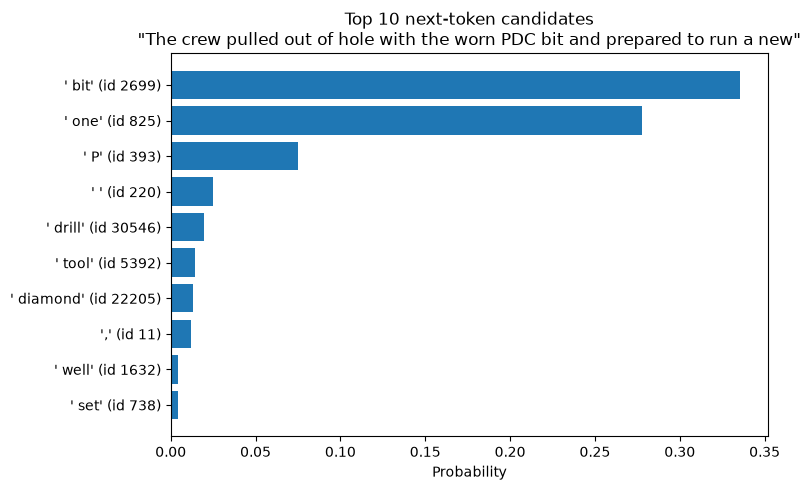

In [12]:
import matplotlib.pyplot as plt


def plot_top_tokens(df: pd.DataFrame, title: str, top_n: int = 10):
    plot_df = df.head(top_n).iloc[::-1]  # reverse so rank 1 appears at the top of the chart
    labels = [f"{row.decoded_token} (id {row.token_id})" for row in plot_df.itertuples()]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(labels, plot_df["probability"])
    ax.set_xlabel("Probability")
    ax.set_title(title)
    fig.tight_layout()
    plt.show()


plot_top_tokens(top_tokens_main, f'Top 10 next-token candidates\n"{PROMPT}"')


## 10. Entropy: how spread out is the model's uncertainty?

Entropy gives us a single number summarizing how concentrated or spread out a
probability distribution is:

$$H = -\sum_i p_i \log p_i$$

- **Lower entropy** → the model's probability mass is concentrated on a few
  tokens (the model is "confident" about a small set of continuations).
- **Higher entropy** → probability is spread across many plausible tokens
  (the model finds many continuations similarly plausible).

Entropy measures uncertainty in the *predicted distribution*. It says nothing
about whether the model's top pick is factually or operationally correct.


In [13]:
def calculate_entropy(probabilities: torch.Tensor) -> float:
    '''Shannon entropy (natural log, in nats) of a probability distribution tensor.'''
    # Cast to float32 before clamping: on MPS/CUDA the model runs in float16, whose
    # smallest representable positive value is far larger than 1e-12, so clamping in
    # float16 would silently round tiny probabilities to exactly 0 and produce NaN.
    p = probabilities.float().clamp_min(1e-12)
    return float(-(p * p.log()).sum().item())


_, _, probs_main = get_next_token_distribution(PROMPT)
entropy_main = calculate_entropy(probs_main)
print(f"Entropy of the next-token distribution for the main prompt: {entropy_main:.3f} nats")


Entropy of the next-token distribution for the main prompt: 3.108 nats


## 11. Context experiments: does changing the sentence change the prediction?

This is the core oilfield lesson. Below are several related, technically
realistic prompts. For each one we compute the actual top-10 next-token
distribution and its entropy — then compare them side by side. We do not
assume in advance what any of them should predict.

- **A:** "The crew pulled out of hole"
- **B:** "The crew pulled out of hole with the worn PDC bit"
- **C:** "The crew pulled out of hole with the worn PDC bit and prepared to run a new" (our main prompt)
- **D:** "The crew pulled out of hole with the production logging tool and prepared to run a new"
- **E:** "The crew pulled out of hole after milling the bridge plug and prepared to run a"
- **F:** "The crew pulled out of hole after reaching section TD and prepared to run a new"


In [14]:
context_prompts = {
    "A": "The crew pulled out of hole",
    "B": "The crew pulled out of hole with the worn PDC bit",
    "C": "The crew pulled out of hole with the worn PDC bit and prepared to run a new",
    "D": "The crew pulled out of hole with the production logging tool and prepared to run a new",
    "E": "The crew pulled out of hole after milling the bridge plug and prepared to run a",
    "F": "The crew pulled out of hole after reaching section TD and prepared to run a new",
}

def compare_prompts(prompts: dict, n: int = 10):
    '''Compute top-n next-token tables and entropy for each named prompt.'''
    tables = {}
    summary_rows = []
    for name, text in prompts.items():
        df = get_top_tokens(text, n=n)
        tables[name] = df
        _, _, probs = get_next_token_distribution(text)
        summary_rows.append({
            "prompt_label": name,
            "prompt_text": text,
            "top_1_token": df.iloc[0]["decoded_token"],
            "top_1_probability_percent": df.iloc[0]["probability_percent"],
            "entropy_nats": calculate_entropy(probs),
        })
    return tables, pd.DataFrame(summary_rows)


context_tables, context_summary = compare_prompts(context_prompts, n=10)
context_summary


,prompt_label,prompt_text,top_1_token,top_1_probability_percent,entropy_nats
0,A,The crew pulled out of hole,' ',20.13%,4.055666
1,B,The crew pulled out of hole with the worn PDC bit,' and',17.72%,3.834699
2,C,The crew pulled out of hole with the worn PDC ...,' bit',33.52%,3.108176
3,D,The crew pulled out of hole with the productio...,' tool',25.88%,3.593982
4,E,The crew pulled out of hole after milling the ...,' cement',8.07%,5.329631
5,F,The crew pulled out of hole after reaching sec...,' section',18.01%,4.914478


In [15]:
for label in context_prompts:
    print(f"--- Prompt {label}: {context_prompts[label]!r} ---")
    display(context_tables[label].head(5))


--- Prompt A: 'The crew pulled out of hole' ---


,rank,token_id,token_repr,decoded_token,logit,probability,probability_percent
0,1,220,'Ġ',' ',19.421875,0.201294,20.13%
1,2,671,'Ġ#',' #',18.593750,0.087952,8.80%
2,3,1372,'Ġnumber',' number',18.390625,0.071777,7.18%
3,4,1283,'Ġafter',' after',18.359375,0.069580,6.96%
4,5,304,'Ġin',' in',18.234375,0.061401,6.14%


--- Prompt B: 'The crew pulled out of hole with the worn PDC bit' ---


,rank,token_id,token_repr,decoded_token,logit,probability,probability_percent
0,1,323,'Ġand',' and',20.828125,0.177246,17.72%
1,2,13,'.','.',20.718750,0.158813,15.88%
2,3,11,"','","','",20.296875,0.104187,10.42%
3,4,304,'Ġin',' in',19.734375,0.059357,5.94%
4,5,624,'.Ċ','.\n',19.500000,0.046967,4.70%


--- Prompt C: 'The crew pulled out of hole with the worn PDC bit and prepared to run a new' ---


...

,rank,token_id,token_repr,decoded_token,logit,probability,probability_percent
0,1,5392,'Ġtool',' tool',19.750000,0.258789,25.88%
1,2,825,'Ġone',' one',19.562500,0.214478,21.45%
2,3,14178,'Ġhole',' hole',18.375000,0.065430,6.54%
3,4,1632,'Ġwell',' well',17.859375,0.039062,3.91%
4,5,2618,'Ġjob',' job',17.546875,0.028580,2.86%


--- Prompt E: 'The crew pulled out of hole after milling the bridge plug and prepared to run a' ---


,rank,token_id,token_repr,decoded_token,logit,probability,probability_percent
0,1,23613,'Ġcement',' cement',18.531250,0.080750,8.07%
1,2,220,'Ġ',' ',18.109375,0.052948,5.29%
2,3,73344,'Ġcasing',' casing',17.765625,0.037567,3.76%
3,4,501,'Ġnew',' new',17.671875,0.034210,3.42%
4,5,65892,'Ġ_____',' _____',17.671875,0.034210,3.42%


--- Prompt F: 'The crew pulled out of hole after reaching section TD and prepared to run a new' ---


,rank,token_id,token_repr,decoded_token,logit,probability,probability_percent
0,1,3772,'Ġsection',' section',19.062500,0.180054,18.01%
1,2,14178,'Ġhole',' hole',18.796875,0.138062,13.81%
2,3,1555,'Ġline',' line',17.796875,0.050781,5.08%
3,4,6021,'Ġroute',' route',17.296875,0.030807,3.08%
4,5,914,'Ġstring',' string',17.234375,0.028931,2.89%


**Interpretation:** compare the `top_1_token` and `entropy_nats` columns
across prompts A-F. Prompts that end mid-sentence with less context tend to
show different (often higher) entropy than prompts that supply a fuller
operational picture — but read the actual numbers above rather than assuming
this pattern; the model's real output is what matters, not our expectation of
it.


## 12. "POOH" alone is ambiguous

**POOH** ("pull out of hole") is not tied to a single operation type. It shows
up in drilling, completions, workover, well intervention, wireline logging,
coiled tubing cleanouts, and fishing jobs. So:

> POOH != a unique operation category

The sentences below all start with POOH but describe very different jobs. We
compute the real next-token distribution for each and compare — this is not a
lookup table mapping POOH to a category, it is five independent model calls.


In [16]:
pooh_prompts = {
    "drilling":     "POOH with worn PDC bit after drilling to section TD, then prepared to run a",
    "perforating":  "POOH with TCP guns after perforating, then prepared to run a",
    "logging":      "POOH with production logging tool after completing the survey, then prepared to run a",
    "cleanout":     "POOH with coiled tubing cleanout BHA, then prepared to run a",
    "fishing":      "POOH with fishing assembly after recovering the fish, then prepared to run a",
}

pooh_tables, pooh_summary = compare_prompts(pooh_prompts, n=10)
pooh_summary


,prompt_label,prompt_text,top_1_token,top_1_probability_percent,entropy_nats
0,drilling,POOH with worn PDC bit after drilling to secti...,' ',25.61%,5.260157
1,perforating,"POOH with TCP guns after perforating, then pre...",' ',11.98%,6.648560
2,logging,POOH with production logging tool after comple...,' production',8.56%,5.777425
3,cleanout,"POOH with coiled tubing cleanout BHA, then pre...",' ',19.09%,5.390667
4,fishing,POOH with fishing assembly after recovering th...,' fishing',4.80%,6.642743


**Interpretation:** the word "POOH" is identical across all five
prompts; only the surrounding operational context differs. Any differences
you see in `top_1_token` or `entropy_nats` above come entirely from that
context — reinforcing that the model is conditioning on the full sequence,
not pattern-matching a single keyword.


## 13. Context ablation: removing words one step at a time

Starting from our main prompt, we progressively strip away context and watch
how the distribution and its entropy change.

- **Full:** "The crew pulled out of hole with the worn PDC bit and prepared to run a new"
- **Ablation 1:** "Pulled out of hole with the worn PDC bit and prepared to run a new"
- **Ablation 2:** "Pulled out of hole with the PDC bit and prepared to run a new"
- **Ablation 3:** "Pulled out of hole and prepared to run a new"
- **Ablation 4:** "Prepared to run a new"


In [17]:
ablation_prompts = {
    "Full":        "The crew pulled out of hole with the worn PDC bit and prepared to run a new",
    "Ablation 1":  "Pulled out of hole with the worn PDC bit and prepared to run a new",
    "Ablation 2":  "Pulled out of hole with the PDC bit and prepared to run a new",
    "Ablation 3":  "Pulled out of hole and prepared to run a new",
    "Ablation 4":  "Prepared to run a new",
}

ablation_tables, ablation_summary = compare_prompts(ablation_prompts, n=10)
ablation_summary


,prompt_label,prompt_text,top_1_token,top_1_probability_percent,entropy_nats
0,Full,The crew pulled out of hole with the worn PDC ...,' bit',33.52%,3.108176
1,Ablation 1,Pulled out of hole with the worn PDC bit and p...,' bit',32.67%,3.082119
2,Ablation 2,Pulled out of hole with the PDC bit and prepar...,' bit',15.83%,4.697844
3,Ablation 3,Pulled out of hole and prepared to run a new,' well',5.00%,6.200665
4,Ablation 4,Prepared to run a new,' business',5.37%,6.794231


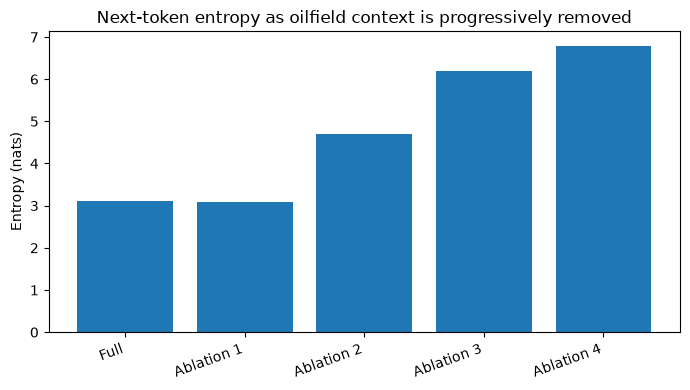

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(ablation_summary["prompt_label"], ablation_summary["entropy_nats"])
ax.set_ylabel("Entropy (nats)")
ax.set_title("Next-token entropy as oilfield context is progressively removed")
ax.tick_params(axis="x", rotation=20)
for label in ax.get_xticklabels():
    label.set_ha("right")
fig.tight_layout()
plt.show()


**Interpretation:** each bar's height is the real entropy of the
model's actual next-token distribution for that ablated prompt — read the
values rather than assuming entropy must rise monotonically as context is
removed; report what the chart actually shows.


## 14. Why not just use a keyword rule?

It would be tempting to write something like:

```python
if "POOH" in text:
    operation = "Well Intervention"
```

This naive rule is intentionally simplistic and is **not** used anywhere in
the model calculations above — it exists only to contrast with what the model
actually does. Let's check it against the POOH prompts from Section 12.


In [19]:
def naive_keyword_rule(text: str) -> str:
    '''Deliberately oversimplified classifier, included only to show why context matters.'''
    return "Well Intervention" if "POOH" in text else "Unclassified"

for label, text in pooh_prompts.items():
    rule_guess = naive_keyword_rule(text)
    print(f"[{label:11s}] rule says: {rule_guess:18s} | actual job: {label}")


[drilling   ] rule says: Well Intervention  | actual job: drilling
[perforating] rule says: Well Intervention  | actual job: perforating
[logging    ] rule says: Well Intervention  | actual job: logging
[cleanout   ] rule says: Well Intervention  | actual job: cleanout
[fishing    ] rule says: Well Intervention  | actual job: fishing


**Interpretation:** the rule outputs the same label ("Well
Intervention") for every prompt, regardless of whether the job was drilling,
perforating, logging, a cleanout, or fishing — because it only looks at one
keyword. The language model, by contrast, conditions on the entire sentence
and produced measurably different distributions for each (Section 12). This
is the difference between pattern-matching a keyword and modeling context.


## 15. What can — and cannot — be claimed about "why" the model chose a token?

We can honestly observe, because we computed them above:

- the exact input tokens that were passed to the model
- the exact final probability distribution over the whole vocabulary
- which candidate token had the highest probability
- how that distribution shifts when we change or remove context

We **cannot** honestly claim:

- "the model chose this token *because* it understood the bit was worn"
- any single-neuron or single-mechanism causal story for the output
- that a probability is the same thing as "confidence" in a human sense
- that the model "understands" oilfield operations the way an engineer does

The correct way to describe what we observed is something like: *"given the
preceding tokens and the statistical patterns learned during training, the
model assigned this token a higher score than the alternatives."* Correlation
between a context change and a probability shift is not, by itself, a
complete mechanistic explanation of the network's internal computation.
Interpretability techniques (e.g. attention analysis, activation patching,
probing) exist to dig further into that question, but they are outside the
scope of this introductory notebook.


## 16. Key lessons

```
Oilfield text
   |
   v
Tokenizer -----------------> token IDs
   |
   v
Transformer ----------------> logits (one raw score per vocabulary token)
   |
   v
Softmax --------------------> probability distribution (sums to 1)
   |
   v
Top candidate next tokens
```

1. LLMs predict tokens, not complete ideas or guaranteed facts.
2. Every token in the vocabulary receives a logit for every prediction step.
3. Logits are converted to probabilities with softmax, computed over the
   *entire* vocabulary.
4. Changing the surrounding oilfield context measurably changes the
   probability distribution — the model is not pattern-matching a keyword.
5. Technical oilfield terms and acronyms may be represented as multiple
   tokens rather than a single one.
6. Every probability shown in this notebook is real model output — none of it
   was hard-coded, predicted in advance, or adjusted after the fact.
7. Observing a probability shift when context changes is not, by itself, a
   complete causal explanation of the model's internal computation.

What comes next (not in this notebook): once a probability distribution
exists, a *decoding strategy* — greedy selection, temperature-scaled
sampling, top-k, or top-p/nucleus sampling — decides which single token
actually gets produced, and generation repeats this whole process one token
at a time. That mechanism is the subject of the next notebook in this series.


## 17. Try your own oilfield sentence

Change only the string below, then run the cell. It will tokenize your
sentence, print the tokens, compute the real top-10 next-token candidates,
plot them, and report the entropy of the distribution — all using the same
`get_top_tokens`, `plot_top_tokens`, and `calculate_entropy` functions defined
earlier in this notebook.


Tokenization:


,position,token_id,decoded_token_repr
0,0,785,'The'
1,1,13627,' crew'
2,2,10613,' ran'
3,3,304,' in'
4,4,14178,' hole'
5,5,448,' with'
6,6,279,' the'
7,7,9755,' completion'
8,8,14614,' assembly'
9,9,323,' and'



Top 10 next-token candidates:


,rank,token_id,token_repr,decoded_token,logit,probability,probability_percent
0,1,4582,'Ġinstall',' install',18.062500,0.056396,5.64%
1,2,1598,'Ġrun',' run',17.796875,0.043243,4.32%
2,3,41740,'Ġassemble',' assemble',17.609375,0.035858,3.59%
3,4,4828,'Ġraise',' raise',17.328125,0.027054,2.71%
4,5,2795,'Ġload',' load',17.265625,0.025421,2.54%
5,6,11893,'Ġlift',' lift',16.968750,0.018890,1.89%
6,7,6815,'Ġpull',' pull',16.937500,0.018311,1.83%
7,8,4057,'Ġremove',' remove',16.906250,0.017746,1.77%
8,9,3271,'Ġmove',' move',16.812500,0.016159,1.62%
9,10,975,'Ġwork',' work',16.718750,0.014709,1.47%


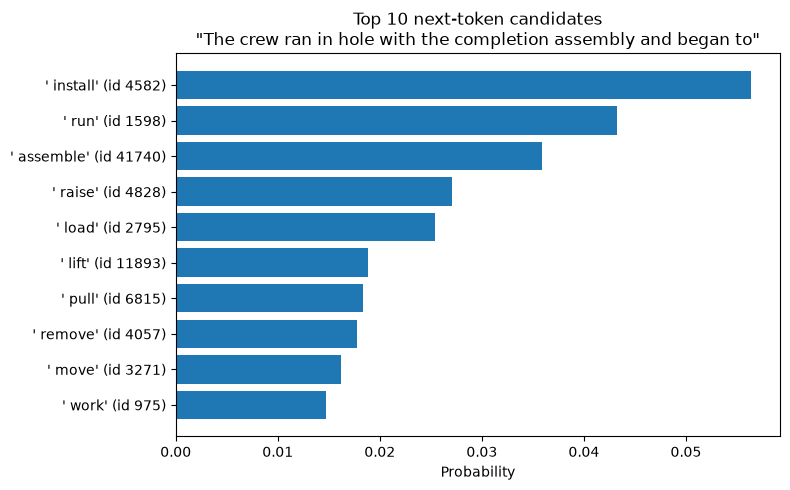


Entropy of this distribution: 5.704 nats
Greedy (argmax) next token:   ' install'


In [20]:
user_prompt = "The crew ran in hole with the completion assembly and began to"  # <-- change this line only

_, user_input_ids, user_decoded_tokens = tokenize_prompt(user_prompt)
print("Tokenization:")
display(pd.DataFrame({
    "position": range(len(user_input_ids)),
    "token_id": user_input_ids.tolist(),
    "decoded_token_repr": [repr(t) for t in user_decoded_tokens],
}))

user_top_tokens = get_top_tokens(user_prompt, n=10)
print("\nTop 10 next-token candidates:")
display(user_top_tokens)

plot_top_tokens(user_top_tokens, f'Top 10 next-token candidates\n"{user_prompt}"')

_, _, user_probs = get_next_token_distribution(user_prompt)
print(f"\nEntropy of this distribution: {calculate_entropy(user_probs):.3f} nats")
print(f"Greedy (argmax) next token:   {user_top_tokens.iloc[0]['decoded_token']}")


## 18. Optional exercises

1. In Section 17, replace "completion assembly" with "PDC bit" and compare the
   top tokens and entropy to Section 8's result.
2. Take the main prompt and remove all operational context (just keep
   "prepared to run a new"). Does entropy go up, down, or stay about the
   same? Check Section 13's ablation table for the actual answer.
3. Try "RIH" (run in hole) in a drilling context vs. a completions context,
   the same way Section 12 did for POOH. Do the distributions differ?
4. Tokenize five more oilfield acronyms of your choice using
   `tokenize_term()` from Section 4a. Which ones split into the most tokens?
5. Write a deliberately ambiguous one-line oilfield sentence and run it
   through Section 17. Is the entropy higher or lower than for prompt C?


## 19. Technical appendix

**Model and environment actually used in this run** (printed live, not
hard-coded):


In [21]:
print(f"Model:                {MODEL_NAME}")
print(f"Device:               {DEVICE}")
print(f"Dtype:                {DTYPE}")
print(f"Vocabulary size:      {model.config.vocab_size:,}")
print(f"Python version:       {sys.version.split()[0]}")
print(f"PyTorch version:      {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")
print(f"Random seed:          {SEED}")


Model:                Qwen/Qwen2.5-1.5B-Instruct
Device:               mps
Dtype:                torch.float16
Vocabulary size:      151,936
Python version:       3.12.13
PyTorch version:      2.14.0
Transformers version: 5.16.1
Random seed:          42


**Raw text vs. chat template.** Qwen2.5-1.5B-Instruct is an
instruction-tuned model, which normally expects input wrapped in a chat
template (special role tokens for system/user/assistant turns). This notebook
deliberately used **raw, unwrapped text** instead, because it makes the
prompt-to-token mapping fully transparent — what you saw fed into
`tokenizer()` in Section 3 is exactly the text above, with no hidden system
prompt or control tokens inserted on your behalf. Wrapping the same prompt in
`tokenizer.apply_chat_template(...)` would very likely shift the next-token
distribution, since the model would then be predicting "what an assistant
says next" rather than "how does this sentence continue" — that comparison is
left for a follow-up notebook.

**Memory and performance notes.** This notebook uses `torch.no_grad()` and
`model.eval()` throughout, only loads one model at a time, and uses float16 on
MPS/CUDA (float32 on CPU) to stay within the memory budget of a normal
laptop.
